#  Indian Mythology SLM — GPT-style Language Model from Scratch

**Domain:** Indian Mythology & Epics (Mahabharata + Ramayana)

**Based on:** Vizuara AI Labs SLM Colab notebook — code kept identical, only the dataset is changed.

**GPU:** T4 (16 GB) — expected training time ~8–9 hours.

> Make sure Runtime is set to **T4 GPU** before running.


## Step 0: Mount Google Drive
Saves checkpoints so a Colab disconnect won't lose your progress.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
SAVE_DIR = '/content/drive/MyDrive/mythology_slm'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Checkpoints will be saved to: {SAVE_DIR}')


Mounted at /content/drive
Checkpoints will be saved to: /content/drive/MyDrive/mythology_slm


##  Step 1: Install Dependencies


In [2]:
!pip install datasets tiktoken requests -q
print('Done')


Done


##  Step 1b: Import the Dataset

**This is the only cell changed from the original notebook.**

Instead of `roneneldan/TinyStories`, we download Indian mythology texts
(Mahabharata + Ramayana) from Project Gutenberg and wrap them in a
HuggingFace `DatasetDict` with the same `{'text': ...}` structure.
All downstream cells (tokenisation, model, training) are untouched.


In [3]:
import requests, re, time, random
from datasets import Dataset, DatasetDict

# Public-domain mythology texts from Project Gutenberg
SOURCES = [
    ('Mahabharata Vol 1', 'https://www.gutenberg.org/cache/epub/15474/pg15474.txt'),
    ('Mahabharata Vol 2', 'https://www.gutenberg.org/cache/epub/15475/pg15475.txt'),
    ('Mahabharata Vol 3', 'https://www.gutenberg.org/cache/epub/15476/pg15476.txt'),
    ('Mahabharata Vol 4', 'https://www.gutenberg.org/cache/epub/15477/pg15477.txt'),
    ('Ramayana',          'https://www.gutenberg.org/cache/epub/24869/pg24869.txt'),
]

def strip_gutenberg(text):
    for m in ['*** START OF THE PROJECT', '*** START OF THIS PROJECT']:
        idx = text.find(m)
        if idx != -1:
            text = text[idx:]; text = text[text.find('\n')+1:]; break
    for m in ['*** END OF THE PROJECT', '*** END OF THIS PROJECT']:
        idx = text.find(m)
        if idx != -1:
            text = text[:idx]; break
    return text.strip()

all_text = ''
for name, url in SOURCES:
    print(f'Downloading {name}...', end=' ')
    try:
        r = requests.get(url, timeout=60); r.raise_for_status()
        t = strip_gutenberg(r.text)
        t = re.sub(r'\r\n', '\n', t)
        t = re.sub(r'[^\x00-\x7F]+', ' ', t)
        t = re.sub(r'\n{4,}', '\n\n\n', t)
        all_text += t + '\n\n'
        print(f'OK  ({len(t):,} chars)')
    except Exception as e:
        print(f'FAILED: {e}')
    time.sleep(1)

print(f'\nTotal corpus: {len(all_text):,} chars  (~{len(all_text)//4:,} tokens)')

# Chunk into ~512 char pieces (like TinyStories stories)
CHUNK = 512; STRIDE = 256
chunks = [all_text[i:i+CHUNK] for i in range(0, len(all_text)-CHUNK, STRIDE)]
random.seed(42); random.shuffle(chunks)

split = int(len(chunks) * 0.95)
ds = DatasetDict({
    'train':      Dataset.from_dict({'text': chunks[:split]}),
    'validation': Dataset.from_dict({'text': chunks[split:]}),
})
print(ds)
print('\n--- Sample chunk ---')
print(ds['train'][0]['text'])



Total corpus: 17,204,705 chars  (~4,301,176 tokens)
DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 63843
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3361
    })
})

--- Sample chunk ---
nd to-day? Do not weep for her, O timid girl, for know
thou that Krishna will come back this very day, and the sons of Pritha,
having slain their foes, will again be united with Yagnaseni!  Thus
addressed by him, Dhatreyika, wiping her beautiful face, replied unto
Indrasena the charioteer, saying,  Disregarding the five Indra-like sons
of Pandu, Jayadratha hath carried away Krishna by force. The track
pursued by him hath not yet disappeared, for the broken branches of trees
have not yet faded. Therefore, tu


##  Step 2: Tokenise the Dataset


In [4]:
!pip install tiktoken
import tiktoken
import os
import numpy as np
from tqdm.auto import tqdm

enc = tiktoken.get_encoding('gpt2')

# Some functions from https://github.com/karpathy/nanoGPT/blob/master/data/openwebtext/prepare.py

def process(example):
    ids = enc.encode_ordinary(example['text'])  # encode_ordinary ignores any special tokens
    out = {'ids': ids, 'len': len(ids)}
    return out

if not os.path.exists('train.bin'):
    tokenized = ds.map(
        process,
        remove_columns=['text'],
        desc='tokenizing the splits',
        num_proc=2,
    )
    for split, dset in tokenized.items():
        arr_len = np.sum(dset['len'], dtype=np.uint64)
        filename = f'{split}.bin'
        dtype = np.uint16  # (can do since enc.max_token_value == 50256 is < 2**16)
        arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,))
        total_batches = 1024

        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
            batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids'])
            arr[idx : idx + len(arr_batch)] = arr_batch
            idx += len(arr_batch)
        arr.flush()

# Print token counts
for s in ['train', 'validation']:
    d = np.memmap(f'{s}.bin', dtype=np.uint16, mode='r')
    print(f'{s}.bin: {len(d):,} tokens')


tokenizing the splits (num_proc=2):   0%|          | 0/63843 [00:00<?, ? examples/s]

tokenizing the splits (num_proc=2):   0%|          | 0/3361 [00:00<?, ? examples/s]

writing train.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

writing validation.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

train.bin: 8,631,572 tokens
validation.bin: 454,190 tokens


##  Step 3: Create Input-Output Batches


In [5]:
# Some functions from https://github.com/karpathy/nanoGPT/blob/master/train.py with slight modifications
# block size = context window
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap('train.bin', dtype=np.uint16, mode='r')
    else:
        data = np.memmap('validation.bin', dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y


##  Step 4: Define the SLM Model Architecture


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer('bias', torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None,
                dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc   = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu   = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1  = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2  = LayerNorm(config.n_embd, config.bias)
        self.mlp  = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte  = nn.Embedding(config.vocab_size, config.n_embd),
            wpe  = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h    = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


##  Step 4b: Model Config


In [7]:
config = GPTConfig(
    vocab_size=50257,     # use the tokenizer's vocab size
    block_size=128,       # or whatever context size you're training with
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.1,
    bias=True
)

model = GPT(config)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}  (~{total_params/1e6:.1f}M)')


Model parameters: 29,995,392  (~30.0M)


## Step 5: Define the Loss Function


In [8]:
def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out


##  Step 6: Training Configuration
 `best_model_params_path` also saves to Google Drive.


In [9]:
# Training Config
import torch
from contextlib import nullcontext

learning_rate = 1e-4
max_iters = 20000
warmup_steps = 1000
min_lr = 5e-4
eval_iters = 500   # batches used to estimate loss
batch_size = 32
block_size = 128

gradient_accumulation_steps = 32

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device_type = 'cuda' if 'cuda' in device else 'cpu'

dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

print(f'Device : {device}  |  dtype : {dtype}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')


Device : cuda  |  dtype : bfloat16
GPU    : Tesla T4


##  Step 7: Optimizer & LR Scheduler


In [10]:
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate,
                               betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9)

scheduler_warmup = LinearLR(optimizer, total_iters=warmup_steps)
scheduler_decay  = CosineAnnealingLR(optimizer, T_max=max_iters - warmup_steps, eta_min=min_lr)
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay],
                         milestones=[warmup_steps])

scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


/tmp/ipykernel_2716/3834439886.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


##  Step 8: Training Loop




In [11]:
import time

best_val_loss = float('inf')
best_model_params_path = 'best_model_params.pt'
train_loss_list, validation_loss_list = [], []

model = model.to(device)

t_start = time.time()

for epoch in tqdm(range(max_iters)):
    if epoch % eval_iters == 0 and epoch != 0:
        losses = estimate_loss(model)
        elapsed = time.time() - t_start
        eta_hrs = ((max_iters - epoch) / epoch * elapsed) / 3600
        print(f'Epoch {epoch}: train loss {losses["train"]:.4f}, val loss {losses["val"]:.4f}  '
              f'| lr {optimizer.param_groups[0]["lr"]:.2e}  | ETA {eta_hrs:.1f}h')
        train_loss_list += [losses['train']]
        validation_loss_list += [losses['val']]

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), best_model_params_path)
            # Also back up to Drive
            try:
                import shutil
                shutil.copy(best_model_params_path, f'{SAVE_DIR}/best_model_params.pt')
                print(f'  -> New best {best_val_loss:.4f} saved locally + Drive')
            except Exception:
                print(f'  -> New best {best_val_loss:.4f} saved locally')

    X, y = get_batch('train')
    X, y = X.to(device), y.to(device)

    with ctx:
        logits, loss = model(X, y)
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

total_hrs = (time.time() - t_start) / 3600
print(f'\nTraining complete! Total time: {total_hrs:.2f}h | Best val loss: {best_val_loss:.4f}')


  0%|          | 0/20000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 500: train loss 9.7363, val loss 9.7346  | lr 6.67e-05  | ETA 3.3h
  -> New best 9.7346 saved locally + Drive
Epoch 1000: train loss 8.9583, val loss 8.9587  | lr 1.00e-04  | ETA 3.2h
  -> New best 8.9587 saved locally + Drive
Epoch 1500: train loss 8.1865, val loss 8.1869  | lr 1.01e-04  | ETA 3.2h
  -> New best 8.1869 saved locally + Drive
Epoch 2000: train loss 7.5145, val loss 7.5204  | lr 1.03e-04  | ETA 3.1h
  -> New best 7.5204 saved locally + Drive
Epoch 2500: train loss 6.9642, val loss 6.9766  | lr 1.06e-04  | ETA 3.0h
  -> New best 6.9766 saved locally + Drive
Epoch 3000: train loss 6.5683, val loss 6.5817  | lr 1.11e-04  | ETA 2.9h
  -> New best 6.5817 saved locally + Drive
Epoch 3500: train loss 6.2269, val loss 6.2456  | lr 1.17e-04  | ETA 2.8h
  -> New best 6.2456 saved locally + Drive
Epoch 4000: train loss 5.9603, val loss 5.9778  | lr 1.24e-04  | ETA 2.8h
  -> New best 5.9778 saved locally + Drive
Epoch 4500: train loss 5.7416, val loss 5.7589  | lr 1.33e-04  | 

##  Step 9: Plot Loss Curves


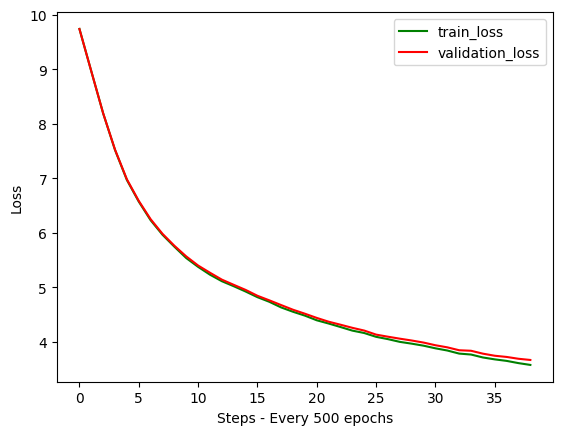

In [12]:
import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() if hasattr(i, 'cpu') else i for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() if hasattr(i, 'cpu') else i for i in validation_loss_list]

plt.plot(train_loss_list_converted, 'g', label='train_loss')
plt.plot(validation_loss_list_converted, 'r', label='validation_loss')
plt.xlabel('Steps - Every 500 epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f'{SAVE_DIR}/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()


##  Step 10: Run SLM Inference



In [13]:
# Load the best model
model = GPT(config)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
best_model_params_path = 'best_model_params.pt'
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device)))
model = model.to(device)
model.eval()
print('Model loaded successfully')


Model loaded successfully


In [14]:
sentence = 'Thus spake Krishna unto Arjuna on the battlefield of Kurukshetra'
context = torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim=0).to(device)
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))


Thus spake Krishna unto Arjuna on the battlefield of Kurukshetra,
abandoning the whip of battle? Besidegding on achieve five mighty a
army, their troops, the king then struck each other, with
bankful arrows shed, like a lion in that14 One day standing on
very scene. Those two mighty car-warriors then, Bhishma, rushed
to conch Vikartana) vigorously among the Kurus, rushed against Bhima,
rewhelmed with rage, and slay Karna hath not exceedingly cheerless! It
purifying the Vrishapras began to pierce the driver of Dussasana,
O king, in that combat that battle between Bhishma and S Firroastrasena and
Fellued with great energy and veribles and husbands: what is that
that all this good man who regards win about king Sasavarma, should soon eat pain
back for even the foe slaying, fight and smiting with his steedsching his



In [15]:
sentence = 'Rama, the eldest son of King Dasharatha, took up his bow'
context = torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim=0).to(device)
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))


Rama, the eldest son of King Dasharatha, took up his bow, saying, 'What high-souled one cometh, viz.,
Aswatthaman, pointing place? Bear me? Tell me thee?
Thou, O igracround in my tone? My death raged
there by me, and I could not fight with the might of my elephant having. But
my husband could obtain thee the old ruler of ocean, so well known
to art anhanded, thou desirest to bring me in this woods for thy
foe. Learning that what he had told his protection, and
endued with guile and untruth, ends in the destruction of Fate and prosperity, O
king, to thee now consisting of Brahmanas. Here, O Brahman, art that hero,
the lord of Men wisement. As Kshatriya who has made an
brother-company of the Earth at the right of Yama attains to a river of justice
named Akachakra, had


In [16]:
sentence = 'The mighty Bhima, born of the wind god, stood before his enemies'
context = torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim=0).to(device)
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))


The mighty Bhima, born of the wind god, stood before his enemies
of his brothers whose front resembled the force of his.


SECTION CCXIX

 Sujaya said,  This is this high-souled Bhishma,
however, the dear daughter of Bhrigu s race, the Vibhatsu of Surasudhi,
obtained it an object of protecting allduties. 

 Sanjaya asked,  O bull of Bharata s race, O mighty Yudhishthira,
when my being expected, thou
winged Rakshasas, O Bharata, thou listen to this, O son of D Gold would
not go into Hiranyortitas. Here also, when the great Lord of
unwara came, a high-souled king (Drona) hath passed in
oma s netherise come with Bhishma. All the Kurus, the Kekayas then,
entered in fear of all sides


In [17]:
sentence = 'O Bharata, hear now the words of dharma'
context = torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim=0).to(device)
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))


O Bharata, hear now the words of dharma, the Pusali,
Yajus- twilight, the sarvijas, the Malaya, theambalas. These men, O
king, follow the worlds as Prajapati.

1364. Vmirupah is evidently read,tivraram. The properties of
treasure are enjoyed by such and read such alleviation.

1226. A said nothing he takes the senses (from desire), with the twang of an infuriated tree with
its hills and Tamas are drawing it at his arms. He have Krishna (on his car,
approaching the feetd, the Gandiva-bhava acts (the form of driver), desireth
to support the caste on the lewd subtile organ of happiness.[50] This men,
is even the knowledge of the Sudra sacrifice of Him. (Time).
She is devoted to the deities in a real nature of all Supreme Being)


In [1]:

from google.colab import runtime
runtime.unassign()


In [1]:
# Cell 1: Configure git
!git config --global user.email "vaishchand26@gmail.com"
!git config --global user.name "defyingGravityy"

In [ ]:
# Cell 2: Create the repo folder and copy files into it
import shutil, os

os.makedirs('/content/indian-mythology-slm', exist_ok=True)
shutil.copy('/content/Indian_Mythology_SLM.ipynb',
            '/content/indian-mythology-slm/')